In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/Cleaned_Superstore.csv")

In [2]:
correlation_matrix = df[
    [
        "Sales",
        "Quantity",
        "Discount",
        "Profit"
    ]
].corr()

In [3]:
correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200722,-0.028311,0.479067
Quantity,0.200722,1.000000,0.008678,0.066211
Discount,-0.028311,0.008678,1.000000,-0.219662
Profit,0.479067,0.066211,-0.219662,1.000000


In [6]:
discount_profit_corr = df[
    "Discount"
    ].corr(
        df["Profit"]
    )
discount_profit_corr

np.float64(-0.21966206449082387)

In [7]:
# Analyze profit by discount
profit_by_discount = df.groupby(
    "Discount"
)["Profit"].agg(
    ["sum","mean","count"]
)

profit_by_discount

,sum,mean,count
Discount,,,
0.00,320844.4073,67.024108,4787
0.10,9029.1770,96.055074,94
0.15,1418.9915,27.288298,52
0.20,90306.6070,24.721217,3653
0.30,-10357.2186,-45.828401,226
0.32,-2391.1377,-88.560656,27
0.40,-23057.0504,-111.927429,206
0.45,-2493.1111,-226.646464,11
0.50,-20506.4281,-310.703456,66


In [8]:
# Sales by discount
sales_by_discount = df.groupby(
    "Discount"
)["Sales"].agg(
    ['sum','mean','count']
)

sales_by_discount

,sum,mean,count
Discount,,,
0.00,1.087278e+06,227.131306,4787
0.10,5.436935e+04,578.397351,94
0.15,2.755852e+04,529.971567,52
0.20,7.645049e+05,209.281397,3653
0.30,1.029453e+05,455.510102,226
0.32,1.449346e+04,536.794770,27
0.40,1.164178e+05,565.134874,206
0.45,5.484974e+03,498.634000,11
0.50,5.891854e+04,892.705152,66


In [9]:
discount_profit = df.groupby(
    "Discount"
)["Profit"].mean()

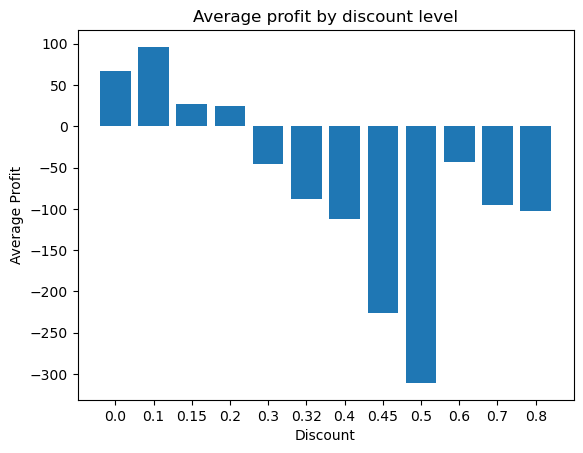

In [10]:
plt.bar(
    discount_profit.index.astype(str),
    discount_profit.values
)

plt.title('Average profit by discount level')

plt.xlabel('Discount')
plt.ylabel('Average Profit')

plt.show()

In [11]:
# sales vs profit by category
category_performance = df.groupby(
    "Category"
).agg(
    Total_Sales = ("Sales","sum"),
    Total_Profit = ("Profit","sum"),
    Average_Discount = ("Discount","mean"),
    Total_Quantity = ("Quantity","sum")
)

category_performance

,Total_Sales,Total_Profit,Average_Discount,Total_Quantity
Category,,,,
Furniture,741306.3133,18421.8137,0.174027,8020
Office Supplies,718735.2440,122364.6608,0.157385,22861
Technology,836154.0330,145454.9481,0.132323,6939


In [12]:
# profit margin = total profit / total sales *100

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

profit_margin = (total_profit/total_sales)*100

profit_margin

np.float64(12.46589897695093)

In [15]:
category_performance["Profit_Margine"] = (
    category_performance["Total_Profit"]/category_performance["Total_Sales"]
)*100

In [16]:
category_performance

,Total_Sales,Total_Profit,Average_Discount,Total_Quantity,Profit_Margine
Category,,,,,
Furniture,741306.3133,18421.8137,0.174027,8020,2.485047
Office Supplies,718735.2440,122364.6608,0.157385,22861,17.024998
Technology,836154.0330,145454.9481,0.132323,6939,17.395712


In [17]:
category_performance.sort_values(
    by = "Profit_Margine",
    ascending=False
)

,Total_Sales,Total_Profit,Average_Discount,Total_Quantity,Profit_Margine
Category,,,,,
Technology,836154.0330,145454.9481,0.132323,6939,17.395712
Office Supplies,718735.2440,122364.6608,0.157385,22861,17.024998
Furniture,741306.3133,18421.8137,0.174027,8020,2.485047
